In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install kagglehub
!pip -q install kagglehub

import os
import shutil
import kagglehub

# Download from KaggleHub
path = kagglehub.dataset_download("hsankesara/flickr-image-dataset")
print("Original download path:", path)

# Copy into Colab working directory
target_path = "/content/flickr_dataset"

if os.path.exists(target_path):
    shutil.rmtree(target_path)

shutil.copytree(path, target_path)

print("Dataset copied to:", target_path)
print("Folders inside /content/flickr_dataset:")
print(os.listdir(target_path))

Using Colab cache for faster access to the 'flickr-image-dataset' dataset.
Original download path: /kaggle/input/flickr-image-dataset
Dataset copied to: /content/flickr_dataset
Folders inside /content/flickr_dataset:
['flickr30k_images']


In [3]:
import os

base_path = "/content/flickr_dataset"

for root, dirs, files in os.walk(base_path):
    print("FOLDER:", root)
    print("Files:", files[:10])   # sirf first 10 files
    print("-"*50)

FOLDER: /content/flickr_dataset
Files: []
--------------------------------------------------
FOLDER: /content/flickr_dataset/flickr30k_images
Files: ['results.csv']
--------------------------------------------------
FOLDER: /content/flickr_dataset/flickr30k_images/flickr30k_images
Files: ['439638376.jpg', '5767811093.jpg', '3471746122.jpg', '2752926645.jpg', '371364900.jpg', '435966316.jpg', '3518414543.jpg', '4898064668.jpg', '4743472747.jpg', '2183877589.jpg']
--------------------------------------------------
FOLDER: /content/flickr_dataset/flickr30k_images/flickr30k_images/flickr30k_images
Files: ['439638376.jpg', '5767811093.jpg', '3471746122.jpg', '2752926645.jpg', '371364900.jpg', '435966316.jpg', '3518414543.jpg', '4898064668.jpg', '4743472747.jpg', '2183877589.jpg']
--------------------------------------------------


In [5]:
import pandas as pd

csv_path = "/content/flickr_dataset/flickr30k_images/results.csv"

df = pd.read_csv(csv_path, sep="|")
print(df.head())
print(df.columns)
print("Shape:", df.shape)

       image_name  comment_number  \
0  1000092795.jpg               0   
1  1000092795.jpg               1   
2  1000092795.jpg               2   
3  1000092795.jpg               3   
4  1000092795.jpg               4   

                                             comment  
0   Two young guys with shaggy hair look at their...  
1   Two young , White males are outside near many...  
2   Two men in green shirts are standing in a yard .  
3       A man in a blue shirt standing in a garden .  
4            Two friends enjoy time spent together .  
Index(['image_name', ' comment_number', ' comment'], dtype='object')
Shape: (158915, 3)


In [6]:
df.columns = df.columns.str.strip()

print(df.columns)
print(df.head())

Index(['image_name', 'comment_number', 'comment'], dtype='object')
       image_name comment_number  \
0  1000092795.jpg              0   
1  1000092795.jpg              1   
2  1000092795.jpg              2   
3  1000092795.jpg              3   
4  1000092795.jpg              4   

                                             comment  
0   Two young guys with shaggy hair look at their...  
1   Two young , White males are outside near many...  
2   Two men in green shirts are standing in a yard .  
3       A man in a blue shirt standing in a garden .  
4            Two friends enjoy time spent together .  


Ek image aur uski captions dekhna

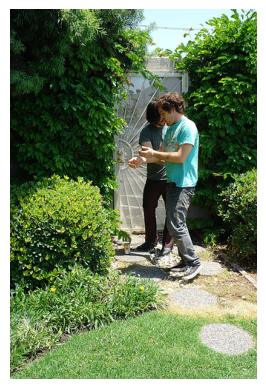

Image: 1000092795.jpg

Captions:
-  Two young guys with shaggy hair look at their hands while hanging out in the yard .
-  Two young , White males are outside near many bushes .
-  Two men in green shirts are standing in a yard .
-  A man in a blue shirt standing in a garden .
-  Two friends enjoy time spent together .


In [7]:
# STEP 4 — Display one image and its captions

import matplotlib.pyplot as plt
from PIL import Image

image_folder = "/content/flickr_dataset/flickr30k_images/flickr30k_images"

# first image name
img_name = df.iloc[0]['image_name']

# image path
img_path = f"{image_folder}/{img_name}"

# load image
img = Image.open(img_path)

# show image
plt.imshow(img)
plt.axis("off")
plt.show()

# show captions of this image
captions = df[df['image_name'] == img_name]['comment'].tolist()

print("Image:", img_name)
print("\nCaptions:")
for c in captions:
    print("-", c)

Image to captions dictionary banana

In [8]:
# STEP 5 — Create image to captions dictionary

image_to_captions = df.groupby('image_name')['comment'].apply(list).to_dict()

print("Total unique images:", len(image_to_captions))

first_key = list(image_to_captions.keys())[0]
print("\nSample image:", first_key)
print("Sample captions:")
for cap in image_to_captions[first_key]:
    print("-", cap)

Total unique images: 31783

Sample image: 1000092795.jpg
Sample captions:
-  Two young guys with shaggy hair look at their hands while hanging out in the yard .
-  Two young , White males are outside near many bushes .
-  Two men in green shirts are standing in a yard .
-  A man in a blue shirt standing in a garden .
-  Two friends enjoy time spent together .


Captions ko clean karna + start/end tokens add karna

In [9]:
# STEP 6 — Clean captions and add <start> <end> tokens

import re

def clean_caption(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z\s]", "", text)   # only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()
    return "<start> " + text + " <end>"

df["clean_comment"] = df["comment"].apply(clean_caption)

print(df[["comment", "clean_comment"]].head())

                                             comment  \
0   Two young guys with shaggy hair look at their...   
1   Two young , White males are outside near many...   
2   Two men in green shirts are standing in a yard .   
3       A man in a blue shirt standing in a garden .   
4            Two friends enjoy time spent together .   

                                       clean_comment  
0  <start> two young guys with shaggy hair look a...  
1  <start> two young white males are outside near...  
2  <start> two men in green shirts are standing i...  
3  <start> a man in a blue shirt standing in a ga...  
4  <start> two friends enjoy time spent together ...  


Clean captions ki new dictionary banana

In [10]:
# STEP 7 — Create image to cleaned captions dictionary

image_to_clean_captions = df.groupby('image_name')['clean_comment'].apply(list).to_dict()

print("Total unique images:", len(image_to_clean_captions))

sample_image = list(image_to_clean_captions.keys())[0]
print("\nSample image:", sample_image)
print("Cleaned captions:")
for cap in image_to_clean_captions[sample_image]:
    print("-", cap)

Total unique images: 31783

Sample image: 1000092795.jpg
Cleaned captions:
- <start> two young guys with shaggy hair look at their hands while hanging out in the yard <end>
- <start> two young white males are outside near many bushes <end>
- <start> two men in green shirts are standing in a yard <end>
- <start> a man in a blue shirt standing in a garden <end>
- <start> two friends enjoy time spent together <end>


Vocabulary banani hai

In [11]:
# STEP 8 — Build vocabulary from cleaned captions

from collections import Counter

all_captions = df["clean_comment"].tolist()

word_counter = Counter()
for caption in all_captions:
    word_counter.update(caption.split())

print("Total unique words:", len(word_counter))

# show most common 20 words
print("\nMost common 20 words:")
for word, count in word_counter.most_common(20):
    print(f"{word}: {count}")

Total unique words: 19772

Most common 20 words:
a: 271705
<start>: 158915
<end>: 158915
in: 83466
the: 62978
on: 45669
and: 44263
man: 42598
is: 41117
of: 38776
with: 36207
woman: 22211
two: 21642
are: 20196
to: 17607
people: 17337
at: 16259
an: 15883
wearing: 15709
young: 13218


Tokenizer banana

In [12]:
# STEP 9 — Create tokenizer and word-index mapping

from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token="<unk>")
tokenizer.fit_on_texts(df["clean_comment"].tolist())

word_index = tokenizer.word_index
index_word = {v: k for k, v in word_index.items()}

vocab_size = len(word_index) + 1

print("Vocabulary size:", vocab_size)
print("\nSample word to index:")
for i, (word, idx) in enumerate(word_index.items()):
    print(f"{word} -> {idx}")
    if i == 9:
        break

Vocabulary size: 19772

Sample word to index:
<unk> -> 1
a -> 2
end -> 3
start -> 4
in -> 5
the -> 6
on -> 7
and -> 8
man -> 9
is -> 10


Maximum caption length nikaalna

In [13]:
# STEP 10 — Find maximum caption length

all_sequences = tokenizer.texts_to_sequences(df["clean_comment"].tolist())
max_length = max(len(seq) for seq in all_sequences)

print("Maximum caption length:", max_length)

# show one sample caption and its tokenized length
sample_caption = df["clean_comment"].iloc[0]
sample_sequence = tokenizer.texts_to_sequences([sample_caption])[0]

print("\nSample caption:", sample_caption)
print("Tokenized sequence:", sample_sequence)
print("Length:", len(sample_sequence))

Maximum caption length: 80

Sample caption: <start> two young guys with shaggy hair look at their hands while hanging out in the yard <end>
Tokenized sequence: [4, 14, 21, 324, 12, 2099, 110, 186, 18, 63, 158, 25, 323, 73, 5, 6, 488, 3]
Length: 18


Train / Validation / Test split banana

In [14]:
# STEP 11 — Split unique images into train/val/test

from sklearn.model_selection import train_test_split

all_images = list(image_to_clean_captions.keys())

train_images, temp_images = train_test_split(all_images, test_size=0.2, random_state=42)
val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)

print("Total images:", len(all_images))
print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Total images: 31783
Train images: 25426
Validation images: 3178
Test images: 3179


Split ke hisaab se clean dictionaries banana

In [15]:
# STEP 12 — Create split-wise caption dictionaries

train_captions = {img: image_to_clean_captions[img] for img in train_images}
val_captions   = {img: image_to_clean_captions[img] for img in val_images}
test_captions  = {img: image_to_clean_captions[img] for img in test_images}

print("Train samples:", len(train_captions))
print("Validation samples:", len(val_captions))
print("Test samples:", len(test_captions))

sample_img = list(train_captions.keys())[0]
print("\nSample train image:", sample_img)
print("Sample train captions:")
for cap in train_captions[sample_img]:
    print("-", cap)

Train samples: 25426
Validation samples: 3178
Test samples: 3179

Sample train image: 531055369.jpg
Sample train captions:
- <start> a woman in purple walking past with a white bag in her hand while an older man and woman are off to the side <end>
- <start> a woman wearing a purple outfit walking down the sidewalk carrying a white bag <end>
- <start> a large woman carrying bags is standing outside of a shop <end>
- <start> three people and a baby carriage in front of a store <end>
- <start> people standing on a sidewalk near shops <end>


Image path function banana

In [16]:
# STEP 13 — Create image path function

import os

image_folder = "/content/flickr_dataset/flickr30k_images/flickr30k_images"

def get_image_path(image_name):
    return os.path.join(image_folder, image_name)

# test
sample_img = list(train_captions.keys())[0]
print("Sample image name:", sample_img)
print("Full path:", get_image_path(sample_img))
print("File exists:", os.path.exists(get_image_path(sample_img)))

Sample image name: 531055369.jpg
Full path: /content/flickr_dataset/flickr30k_images/flickr30k_images/531055369.jpg
File exists: True


Image preprocessing (resize + normalize)

In [17]:
# STEP 14 — Image preprocessing function

import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

def preprocess_image(image_path):

    img = load_img(image_path, target_size=(224,224))
    img = img_to_array(img)

    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    return img

# test preprocessing
sample_img = list(train_captions.keys())[0]
img_path = get_image_path(sample_img)

processed_img = preprocess_image(img_path)

print("Processed image shape:", processed_img.shape)

Processed image shape: (1, 224, 224, 3)


ResNet encoder load karna aur ek image ke features nikaalna

In [18]:
# STEP 15 — Load ResNet50 encoder and extract one image feature vector

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

# pretrained ResNet50
base_model = ResNet50(weights='imagenet')

# remove final classification layer
cnn_encoder = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)

# test on one image
sample_img = list(train_captions.keys())[0]
img_path = get_image_path(sample_img)

processed_img = preprocess_image(img_path)
feature_vector = cnn_encoder.predict(processed_img, verbose=0)

print("Feature vector shape:", feature_vector.shape)

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Feature vector shape: (1, 2048)


Train/Val/Test images ke features extract karke Google Drive me save karna

In [19]:
# STEP 16 — Extract features for train/val/test images and save to Google Drive

import os
import pickle
from tqdm import tqdm

# make sure Drive is mounted already
save_dir = "/content/drive/MyDrive/image_captioning_project"
os.makedirs(save_dir, exist_ok=True)

def extract_features_for_images(image_list):
    features = {}
    for img_name in tqdm(image_list):
        img_path = get_image_path(img_name)
        try:
            img = preprocess_image(img_path)
            feature = cnn_encoder.predict(img, verbose=0)
            features[img_name] = feature[0]   # shape becomes (2048,)
        except Exception as e:
            print(f"Error with {img_name}: {e}")
    return features

# extract features
train_features = extract_features_for_images(train_images)
val_features   = extract_features_for_images(val_images)
test_features  = extract_features_for_images(test_images)

# save to drive
with open(os.path.join(save_dir, "train_features.pkl"), "wb") as f:
    pickle.dump(train_features, f)

with open(os.path.join(save_dir, "val_features.pkl"), "wb") as f:
    pickle.dump(val_features, f)

with open(os.path.join(save_dir, "test_features.pkl"), "wb") as f:
    pickle.dump(test_features, f)

print("Saved files:")
print(os.path.join(save_dir, "train_features.pkl"))
print(os.path.join(save_dir, "val_features.pkl"))
print(os.path.join(save_dir, "test_features.pkl"))

print("\nCounts:")
print("Train features:", len(train_features))
print("Val features:", len(val_features))
print("Test features:", len(test_features))

100%|██████████| 3179/3179 [05:48<00:00,  9.13it/s]


Saved files:
/content/drive/MyDrive/image_captioning_project/train_features.pkl
/content/drive/MyDrive/image_captioning_project/val_features.pkl
/content/drive/MyDrive/image_captioning_project/test_features.pkl

Counts:
Train features: 25426
Val features: 3178
Test features: 3179


Ek caption ko token sequence me convert karke samajhna

In [20]:
# STEP 17 — Convert one cleaned caption into token sequence

sample_img = list(train_captions.keys())[0]
sample_caption = train_captions[sample_img][0]

sequence = tokenizer.texts_to_sequences([sample_caption])[0]

print("Sample image:", sample_img)
print("Sample cleaned caption:")
print(sample_caption)

print("\nToken sequence:")
print(sequence)

print("\nSequence length:", len(sequence))

Sample image: 531055369.jpg
Sample cleaned caption:
<start> a woman in purple walking past with a white bag in her hand while an older man and woman are off to the side <end>

Token sequence:
[4, 2, 13, 5, 193, 41, 251, 12, 2, 22, 241, 5, 40, 132, 25, 19, 109, 9, 8, 13, 15, 114, 16, 6, 147, 3]

Sequence length: 26


Training pairs

In [21]:
# STEP 18 — Create training pairs from one caption

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

sample_img = list(train_captions.keys())[0]
sample_caption = train_captions[sample_img][0]
seq = tokenizer.texts_to_sequences([sample_caption])[0]

print("Sample caption:")
print(sample_caption)
print("\nFull sequence:")
print(seq)

print("\nTraining pairs:\n")

for i in range(1, len(seq)):
    in_seq = seq[:i]
    out_seq = seq[i]

    padded_in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]

    print(f"Input sequence {i}: {in_seq}")
    print(f"Padded input {i}: {padded_in_seq}")
    print(f"Next word id {i}: {out_seq}")
    print("-" * 80)

    if i == 5:   # sirf first 5 pairs show kar rahe hain
        break

Sample caption:
<start> a woman in purple walking past with a white bag in her hand while an older man and woman are off to the side <end>

Full sequence:
[4, 2, 13, 5, 193, 41, 251, 12, 2, 22, 241, 5, 40, 132, 25, 19, 109, 9, 8, 13, 15, 114, 16, 6, 147, 3]

Training pairs:

Input sequence 1: [4]
Padded input 1: [4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]
Next word id 1: 2
--------------------------------------------------------------------------------
Input sequence 2: [4, 2]
Padded input 2: [4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]
Next word id 2: 13
--------------------------------------------------------------------------------
Input sequence 3: [4, 2, 13]
Padded input 3: [ 4  2 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0


Data generator

In [22]:
# STEP 19 — Create training data generator

import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

def data_generator(captions_dict, features_dict, tokenizer, max_length, vocab_size, batch_size=32):
    image_names = list(captions_dict.keys())

    while True:
        X1, X2, y = [], [], []

        for img_name in image_names:
            feature = features_dict[img_name]
            captions = captions_dict[img_name]

            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield ([np.array(X1), np.array(X2)], np.array(y))
                        X1, X2, y = [], [], []

print("Generator function created successfully.")

Generator function created successfully.


Generator function created successfully.

In [23]:
# STEP 20 — Test one batch from generator

train_generator = data_generator(
    captions_dict=train_captions,
    features_dict=train_features,
    tokenizer=tokenizer,
    max_length=max_length,
    vocab_size=vocab_size,
    batch_size=32
)

(X1_batch, X2_batch), y_batch = next(train_generator)

print("Image feature batch shape:", X1_batch.shape)
print("Caption input batch shape:", X2_batch.shape)
print("Output batch shape:", y_batch.shape)

print("\nSample caption input sequence:")
print(X2_batch[0])

print("\nSample image feature vector shape:")
print(X1_batch[0].shape)

print("\nSample output one-hot vector shape:")
print(y_batch[0].shape)

Image feature batch shape: (32, 2048)
Caption input batch shape: (32, 80)
Output batch shape: (32, 19772)

Sample caption input sequence:
[4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]

Sample image feature vector shape:
(2048,)

Sample output one-hot vector shape:
(19772,)


mage Captioning model

In [24]:
# STEP 21 — Build image captioning model

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Dropout, Add

# image feature branch
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# text sequence branch
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

# decoder
decoder1 = Add()([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# final model
model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 80, 256)   │  5,061,632 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 80)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 19772)     │  5,081,404 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,258,684 (42.95 MB)

 Trainable params: 11,258,684 (42.95 MB)

 Non-trainable params: 0 (0.00 B)

None


EarlyStopping + Checkpoint

In [25]:
# STEP 22 — Prepare generators, steps, checkpoint, and early stopping

import os
import math
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

save_dir = "/content/drive/MyDrive/image_captioning_project"
os.makedirs(save_dir, exist_ok=True)

train_generator = data_generator(
    captions_dict=train_captions,
    features_dict=train_features,
    tokenizer=tokenizer,
    max_length=max_length,
    vocab_size=vocab_size,
    batch_size=32
)

val_generator = data_generator(
    captions_dict=val_captions,
    features_dict=val_features,
    tokenizer=tokenizer,
    max_length=max_length,
    vocab_size=vocab_size,
    batch_size=32
)

def count_total_samples(captions_dict, tokenizer):
    total = 0
    for img_name, captions in captions_dict.items():
        for caption in captions:
            seq = tokenizer.texts_to_sequences([caption])[0]
            total += (len(seq) - 1)
    return total

train_samples = count_total_samples(train_captions, tokenizer)
val_samples = count_total_samples(val_captions, tokenizer)

steps_per_epoch = math.ceil(train_samples / 32)
validation_steps = math.ceil(val_samples / 32)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(save_dir, "model_epoch_{epoch:02d}.keras"),
    save_best_only=False,
    save_weights_only=False,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

epochs = 10

print("Train samples:", train_samples)
print("Validation samples:", val_samples)
print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)
print("Epochs:", epochs)
print("EarlyStopping: ON")

Train samples: 1684909
Validation samples: 209912
Steps per epoch: 52654
Validation steps: 6560
Epochs: 10
EarlyStopping: ON


In [27]:
# STEP 23 — Fix generator to return tuple instead of list

import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

def data_generator(captions_dict, features_dict, tokenizer, max_length, vocab_size, batch_size=32):
    image_names = list(captions_dict.keys())

    while True:
        X1, X2, y = [], [], []

        for img_name in image_names:
            feature = features_dict[img_name]
            captions = captions_dict[img_name]

            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
                    out_seq = to_categorical(out_seq, num_classes=vocab_size)

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield ((np.array(X1, dtype="float32"),
                                np.array(X2, dtype="int32")),
                               np.array(y, dtype="float32"))
                        X1, X2, y = [], [], []

print("Generator fixed successfully.")

Generator fixed successfully.


Training run

In [29]:
# STEP 24 — Recreate generators from the fixed generator function

train_generator = data_generator(
    captions_dict=train_captions,
    features_dict=train_features,
    tokenizer=tokenizer,
    max_length=max_length,
    vocab_size=vocab_size,
    batch_size=32
)

val_generator = data_generator(
    captions_dict=val_captions,
    features_dict=val_features,
    tokenizer=tokenizer,
    max_length=max_length,
    vocab_size=vocab_size,
    batch_size=32
)

print("New train and validation generators created successfully.")

New train and validation generators created successfully.


In [30]:
# STEP 25 — Start training with recreated generators

history = model.fit(
    train_generator,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/10
52651/52654 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.3938
Epoch 1: saving model to /content/drive/MyDrive/image_captioning_project/model_epoch_01.keras
52654/52654 ━━━━━━━━━━━━━━━━━━━━ 917s 17ms/step - loss: 4.3938 - val_loss: 3.8446
Epoch 2/10
52654/52654 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.8470
Epoch 2: saving model to /content/drive/MyDrive/image_captioning_project/model_epoch_02.keras
52654/52654 ━━━━━━━━━━━━━━━━━━━━ 922s 18ms/step - loss: 3.8470 - val_loss: 3.8299
Epoch 3/10
52653/52654 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.8046
Epoch 3: saving model to /content/drive/MyDrive/image_captioning_project/model_epoch_03.keras
52654/52654 ━━━━━━━━━━━━━━━━━━━━ 911s 17ms/step - loss: 3.8046 - val_loss: 3.8451
Epoch 4/10
52652/52654 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3.8084
Epoch 4: saving model to /content/drive/MyDrive/image_captioning_project/model_epoch_04.keras
52654/52654 ━━━━━━━━━━━━━━━━━━━━ 918s 17ms/step - loss: 3.8084 - val_loss: 3.8749
Epoch 4:

Best model ko final naam se Drive me save karo

In [31]:
# STEP 27 — Save final best model

final_model_path = "/content/drive/MyDrive/image_captioning_project/best_caption_model.keras"
model.save(final_model_path)

print("Best model saved at:")
print(final_model_path)

Best model saved at:
/content/drive/MyDrive/image_captioning_project/best_caption_model.keras


Caption generate karne ka function banana

In [32]:
# STEP 28 — Caption generation function

def generate_caption(model, feature, tokenizer, max_length):

    in_text = "start"

    for i in range(max_length):

        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')

        yhat = model.predict([feature, sequence], verbose=0)
        yhat = np.argmax(yhat)

        word = index_word.get(yhat)

        if word is None:
            break

        in_text += " " + word

        if word == "end":
            break

    return in_text

Test image par caption generate karo

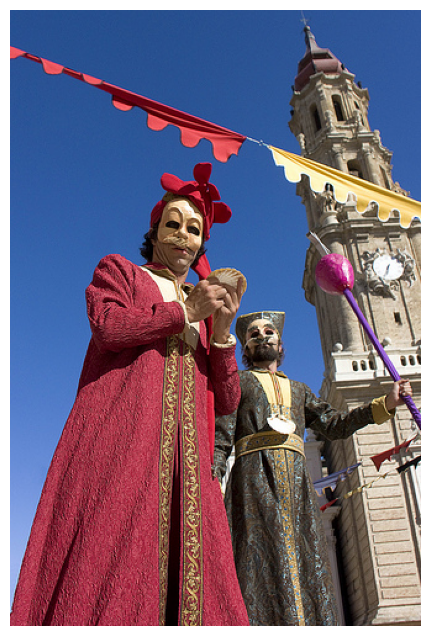

Image: 4669564767.jpg
Generated Caption: start a man in a black shirt is sitting on a bench with a man in a blue shirt end

Ground Truth Captions:
- <start> two people who are wearing colorful robes and masks are standing next to a tall white tower <end>
- <start> the men in the long dress wardrobe are putting on a show <end>
- <start> two masked clowns posing in front of a cathedral <end>
- <start> people dressed in costumes by a clock tower <end>
- <start> people on stilts in a parade <end>


In [33]:
# STEP 29 — Generate caption for one test image

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

sample_test_img = list(test_captions.keys())[0]
sample_feature = np.expand_dims(test_features[sample_test_img], axis=0)

generated_caption = generate_caption(model, sample_feature, tokenizer, max_length)

img = Image.open(get_image_path(sample_test_img))
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

print("Image:", sample_test_img)
print("Generated Caption:", generated_caption)
print("\nGround Truth Captions:")
for cap in test_captions[sample_test_img]:
    print("-", cap)

In [34]:
# STEP 30 — Clean generated caption for display

def clean_generated_caption(caption):
    words = caption.split()
    words = [w for w in words if w not in ["start", "end"]]
    return " ".join(words)

sample_test_img = list(test_captions.keys())[0]
sample_feature = np.expand_dims(test_features[sample_test_img], axis=0)

generated_caption = generate_caption(model, sample_feature, tokenizer, max_length)
clean_caption = clean_generated_caption(generated_caption)

print("Raw Caption:")
print(generated_caption)

print("\nClean Caption:")
print(clean_caption)

Raw Caption:
start a man in a black shirt is sitting on a bench with a man in a blue shirt end

Clean Caption:
a man in a black shirt is sitting on a bench with a man in a blue shirt


5 test images par captions generate karna

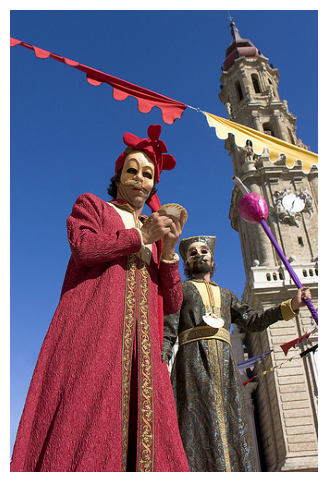

Image: 4669564767.jpg
Generated Caption: a man in a black shirt is sitting on a bench with a man in a blue shirt
Ground Truth Captions:
- <start> two people who are wearing colorful robes and masks are standing next to a tall white tower <end>
- <start> the men in the long dress wardrobe are putting on a show <end>
- <start> two masked clowns posing in front of a cathedral <end>
- <start> people dressed in costumes by a clock tower <end>
- <start> people on stilts in a parade <end>


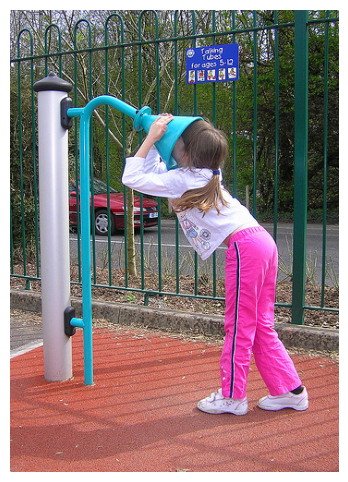

Image: 455709770.jpg
Generated Caption: a man in a black shirt is sitting on a bench with a man in a blue shirt
Ground Truth Captions:
- <start> a little girl wearing pink pants pink and white tennis shoes and a white shirt with a little girl on it puts her face in a blue talking tube <end>
- <start> a girl wearing bright pink pants sticks her face into the coneshaped end of a talking tube in a park <end>
- <start> a little girl with bright pink pants playfully sticks her face in a contraption on a playground <end>
- <start> a young girl in a white shirt and pink pants with her head in a talking tube outdoors <end>
- <start> a girl is putting her face into a blue cone <end>


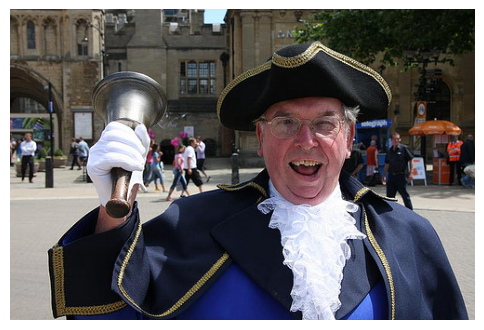

Image: 2710027673.jpg
Generated Caption: a man in a black shirt is sitting on a bench with a man in a blue shirt
Ground Truth Captions:
- <start> an older man dressed in blue historical clothing is ringing a bell in his right hand <end>
- <start> a older man in a revolutionary type costume is ringing a bell on a street <end>
- <start> a man dressed in a colonial costume is smiling and holding up a bell <end>
- <start> a man wearing revolutionary period clothes is ringing a bell <end>
- <start> a man in costume is ringing a bell <end>


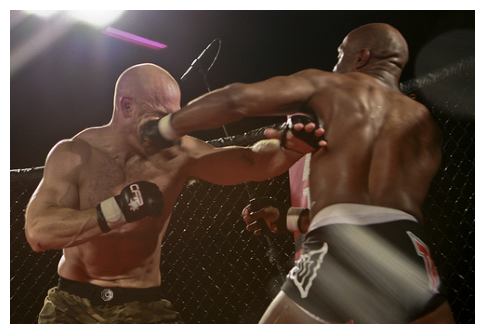

Image: 3527320221.jpg
Generated Caption: a man in a black shirt is sitting on a bench with a man in a blue shirt
Ground Truth Captions:
- <start> two bald boxers are fighting the one on the left is being punched in the face by the darkerskinned boxer on the right who is throwing a left hook <end>
- <start> a black boxer has just landed hit with his left glove on the cheek of a white boxer <end>
- <start> two cage fighters both shirtless fight against each other in a cage <end>
- <start> two guys with no shirts on are throwing punches while in a cage <end>
- <start> one fighter delivers a hard blow to the face of another fighter <end>


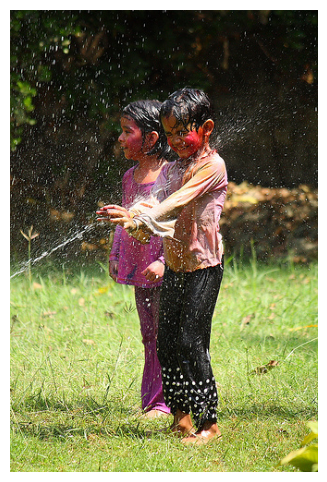

Image: 3347666612.jpg
Generated Caption: a man in a black shirt is sitting on a bench with a man in a blue shirt
Ground Truth Captions:
- <start> children with painted red faces being sprayed with water on grass <end>
- <start> two children standing in the grass being sprayed by a hose <end>
- <start> two indian children are being squirted by a jet of water <end>
- <start> the two children are being sprayed by water <end>
- <start> two children playing in a spray of water <end>


In [35]:
# STEP 31 — Generate captions for 5 test images

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

test_image_list = list(test_captions.keys())[:5]

for img_name in test_image_list:
    feature = np.expand_dims(test_features[img_name], axis=0)

    generated_caption = generate_caption(model, feature, tokenizer, max_length)
    clean_caption = clean_generated_caption(generated_caption)

    img = Image.open(get_image_path(img_name))
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Image:", img_name)
    print("Generated Caption:", clean_caption)
    print("Ground Truth Captions:")
    for cap in test_captions[img_name]:
        print("-", cap)
    print("="*100)